In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga inicial
df = pd.read_csv('dataset_elpino.csv', sep=';', na_values='-', low_memory=False)

--- ANÁLISIS DE COMPLETITUD ---

Top 15 columnas con más datos faltantes:
                         Columna  Porcentaje_Faltante
0   Diag 35 Secundario (cod+des)            99.807706
1   Diag 34 Secundario (cod+des)            99.725294
2   Diag 33 Secundario (cod+des)            99.704691
3   Diag 32 Secundario (cod+des)            99.608543
4   Diag 31 Secundario (cod+des)            99.539867
5   Diag 30 Secundario (cod+des)            99.478058
6   Diag 29 Secundario (cod+des)            99.361308
7   Diag 28 Secundario (cod+des)            99.244557
8   Diag 27 Secundario (cod+des)            99.107204
9   Diag 26 Secundario (cod+des)            98.942380
10  Diag 25 Secundario (cod+des)            98.667674
11  Diag 24 Secundario (cod+des)            98.523453
12  Diag 23 Secundario (cod+des)            98.262482
13  Diag 22 Secundario (cod+des)            97.912231
14  Diag 21 Secundario (cod+des)            97.575716


/tmp/ipykernel_34495/2017500056.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='Porcentaje_Faltante', y='Columna', palette='viridis')


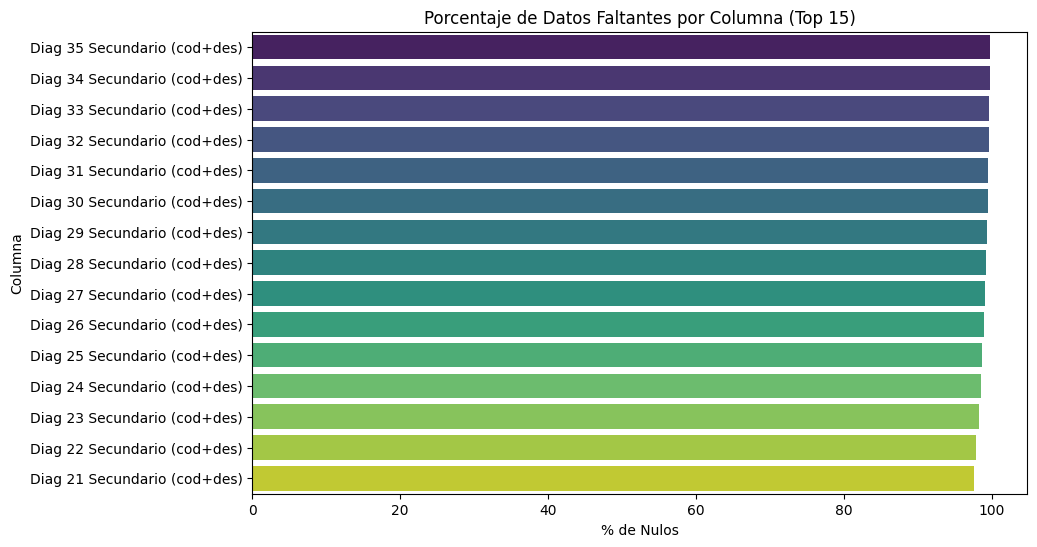


Resumen de nulos por fila:
count    14561.000000
mean        44.608543
std         11.404394
min          0.000000
25%         40.000000
50%         47.000000
75%         53.000000
max         63.000000
Name: nulos_por_fila, dtype: float64


In [3]:
# --- COMPLETITUD ---
print("--- ANÁLISIS DE COMPLETITUD ---")
# 1. Porcentaje de valores nulos por columna (Top 15 con más faltantes)
missing_pct = df.isnull().mean() * 100
missing_df = missing_pct.sort_values(ascending=False).head(15).reset_index()
missing_df.columns = ['Columna', 'Porcentaje_Faltante']

print("\nTop 15 columnas con más datos faltantes:")
print(missing_df)

# Visualización de nulos por columna
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df, x='Porcentaje_Faltante', y='Columna', palette='viridis')
plt.title('Porcentaje de Datos Faltantes por Columna (Top 15)')
plt.xlabel('% de Nulos')
plt.show()

# 2. Análisis de registros (Filas)
df['nulos_por_fila'] = df.isnull().sum(axis=1)
print(f"\nResumen de nulos por fila:\n{df['nulos_por_fila'].describe()}")

In [4]:
# --- CORRECTITUD ---
print("\n--- ANÁLISIS DE CORRECTITUD ---")

# 1. Conversión y validación de tipos
df['Edad'] = pd.to_numeric(df['Edad en años'], errors='coerce')
print(f"Valores de Edad no numéricos detectados: {df['Edad'].isnull().sum()}")

# 2. Consistencia de variables categóricas
print("\nDistribución por Sexo:")
print(df['Sexo (Desc)'].value_counts(dropna=False))

# 3. Creación de variables de complejidad clínica (Correctitud de registros)
diag_cols = [col for col in df.columns if col.startswith('Diag')]
proc_cols = [col for col in df.columns if col.startswith('Proced')]

df['num_diagnosticos'] = df[diag_cols].notnull().sum(axis=1)
df['num_procedimientos'] = df[proc_cols].notnull().sum(axis=1)

print("\nEstadísticas de Diagnósticos y Procedimientos por paciente:")
print(df[['num_diagnosticos', 'num_procedimientos']].describe())


--- ANÁLISIS DE CORRECTITUD ---
Valores de Edad no numéricos detectados: 0

Distribución por Sexo:
Sexo (Desc)
Mujer     9617
Hombre    4944
Name: count, dtype: int64

Estadísticas de Diagnósticos y Procedimientos por paciente:
       num_diagnosticos  num_procedimientos
count      14561.000000        14561.000000
mean           7.173958           13.217499
std            5.220577            7.362028
min            1.000000            1.000000
25%            3.000000            8.000000
50%            6.000000           11.000000
75%           10.000000           16.000000
max           35.000000           30.000000



--- ANÁLISIS DE OUTLIERS ---
Outliers detectados en Edad (sobre 115.50): 1
Outliers detectados en num_diagnosticos (sobre 20.50): 353
Outliers detectados en num_procedimientos (sobre 28.00): 1182


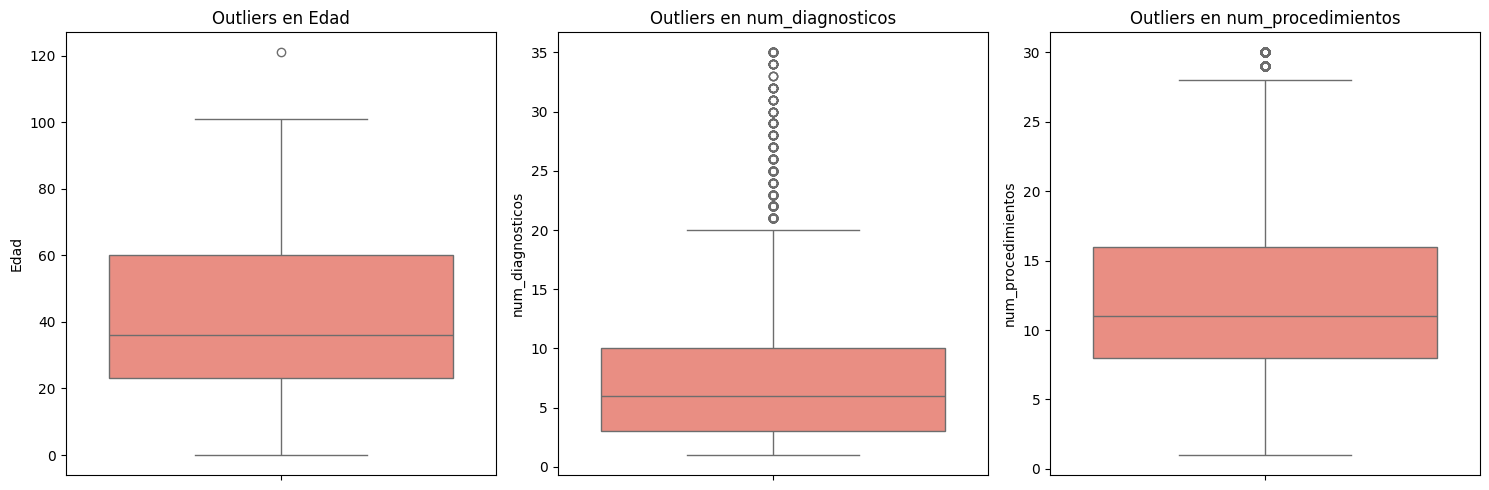

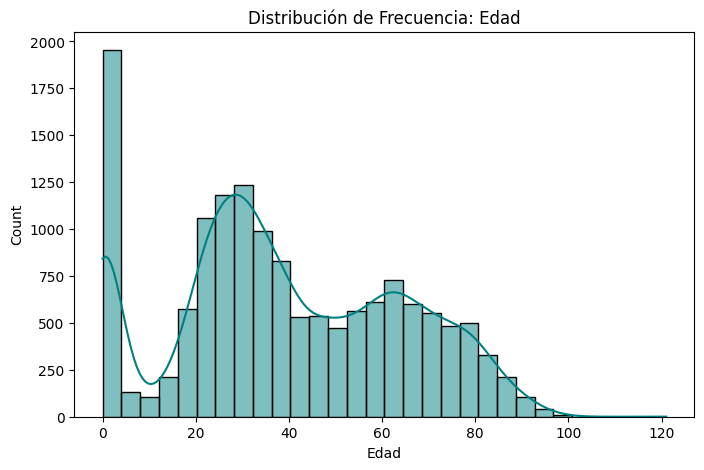

In [5]:
# --- OUTLIERS ---
print("\n--- ANÁLISIS DE OUTLIERS ---")

variables_interes = ['Edad', 'num_diagnosticos', 'num_procedimientos']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_interes):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[var], color='salmon')
    plt.title(f'Outliers en {var}')

    # Cálculo de límites usando IQR
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    outliers_count = (df[var] > lim_sup).sum()
    print(f"Outliers detectados en {var} (sobre {lim_sup:.2f}): {outliers_count}")

plt.tight_layout()
plt.show()

# Histograma de Edad para ver la distribución de correctitud
plt.figure(figsize=(8, 5))
sns.histplot(df['Edad'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribución de Frecuencia: Edad')
plt.show()

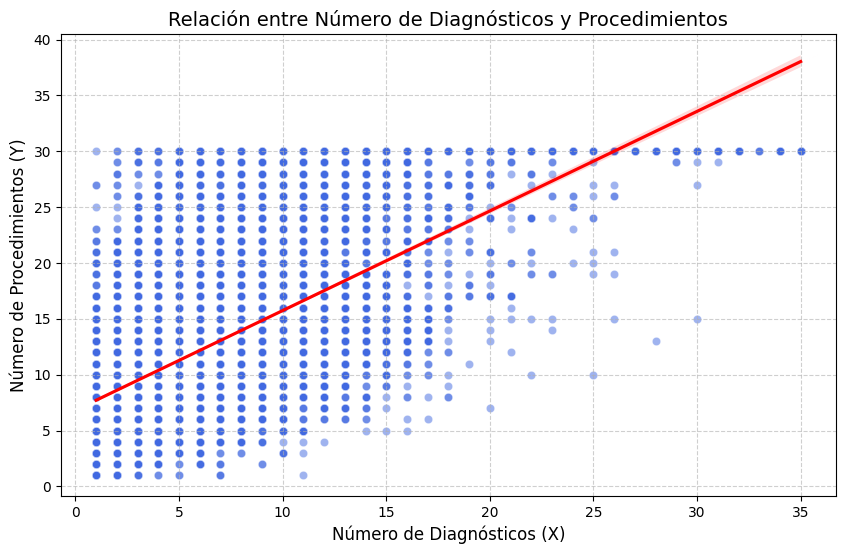

In [6]:
# Crear el gráfico x vs y (Diagnósticos vs Procedimientos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='num_diagnosticos', y='num_procedimientos', alpha=0.5, color='royalblue')

# Añadir una línea de tendencia para ver la relación
sns.regplot(data=df, x='num_diagnosticos', y='num_procedimientos', scatter=False, color='red')

plt.title('Relación entre Número de Diagnósticos y Procedimientos', fontsize=14)
plt.xlabel('Número de Diagnósticos (X)', fontsize=12)
plt.ylabel('Número de Procedimientos (Y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

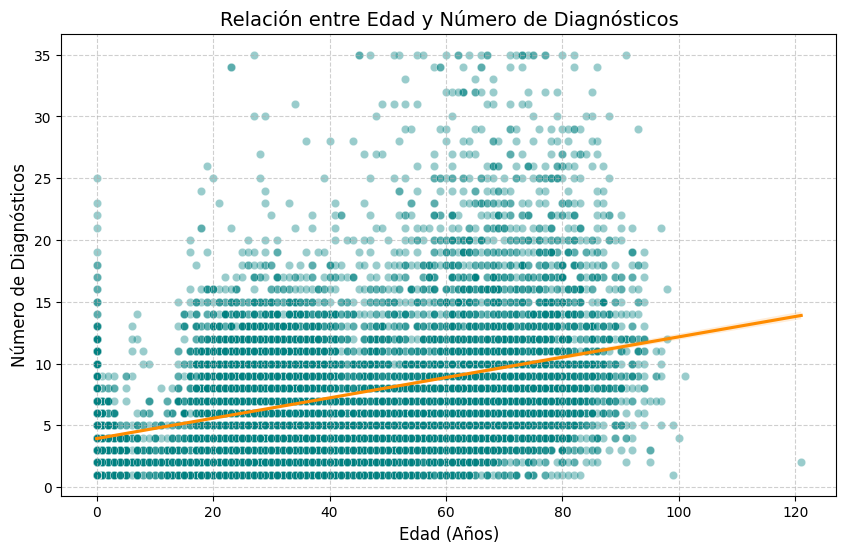

In [7]:
# Crear el gráfico x vs y (Edad vs Diagnósticos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Edad', y='num_diagnosticos', alpha=0.4, color='teal')

# Añadir una línea de tendencia (regresión)
sns.regplot(data=df, x='Edad', y='num_diagnosticos', scatter=False, color='darkorange')

plt.title('Relación entre Edad y Número de Diagnósticos', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Número de Diagnósticos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

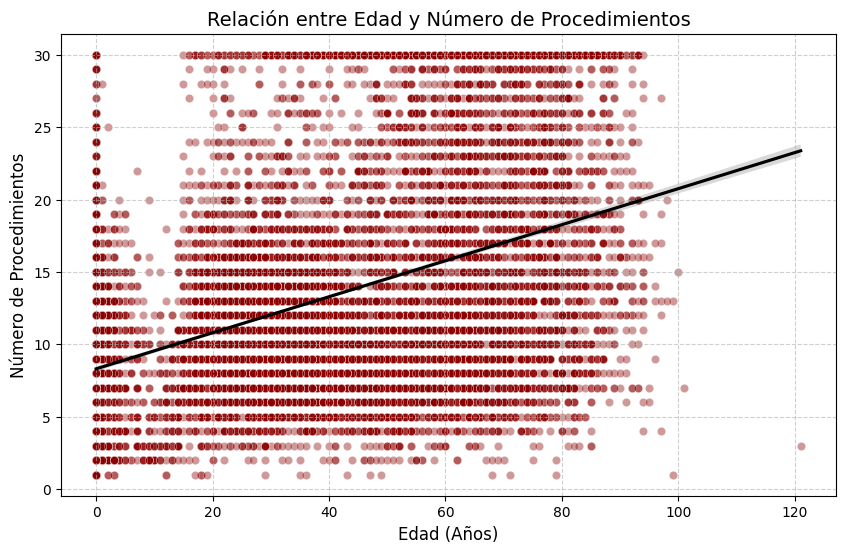

In [8]:
# Crear el gráfico x vs y (Edad vs Procedimientos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Edad', y='num_procedimientos', alpha=0.4, color='darkred')

# Añadir una línea de tendencia (regresión)
sns.regplot(data=df, x='Edad', y='num_procedimientos', scatter=False, color='black')

plt.title('Relación entre Edad y Número de Procedimientos', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Número de Procedimientos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()